In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import os, sys

!git clone https://github.com/facebookresearch/sam2.git /kaggle/working/sam2 -q
os.chdir('/kaggle/working/sam2')
!pip install -e . -q
!wget -q -P /kaggle/working/sam2/checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt
!git clone https://github.com/sczhou/ProPainter.git /kaggle/working/ProPainter -q
!pip install -r /kaggle/working/ProPainter/requirements.txt -q
!wget -q -O /kaggle/working/test_video.mp4 "https://download.blender.org/peach/bigbuckbunny_movies/BigBuckBunny_320x180.mp4"
os.makedirs('/kaggle/working/frames', exist_ok=True)
!ffmpeg -i /kaggle/working/test_video.mp4 -vf "select=gte(n\,2000)*lte(n\,2100)" -vsync 0 -q:v 2 /kaggle/working/frames/%05d.jpg -hide_banner -loglevel quiet

print("✅ ALL SETUP DONE!")

fatal: destination path '/kaggle/working/sam2' already exists and is not an empty directory.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for SAM-2 (pyproject.toml) ... done
fatal: destination path '/kaggle/working/ProPainter' already exists and is not an empty directory.
✅ ALL SETUP DONE!


In [4]:
import os, sys, torch, numpy as np, cv2
from hydra.core.global_hydra import GlobalHydra
from hydra import initialize_config_dir
from sam2.build_sam import build_sam2_video_predictor

os.chdir('/kaggle/working/sam2')
sys.path.insert(0, '/kaggle/working/sam2')
GlobalHydra.instance().clear()

with initialize_config_dir(config_dir="/kaggle/working/sam2/sam2/configs/sam2.1", version_base=None):
    predictor = build_sam2_video_predictor(
        "sam2.1_hiera_l.yaml",
        "/kaggle/working/sam2/checkpoints/sam2.1_hiera_large.pt",
        device="cuda"
    )

inference_state = predictor.init_state(video_path="/kaggle/working/frames")

predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=0,
    obj_id=1,
    points=np.array([[100, 90]], dtype=np.float32),
    labels=np.array([1], dtype=np.int32)
)

video_segments = {}
for frame_idx, object_ids, masks in predictor.propagate_in_video(inference_state):
    video_segments[frame_idx] = {
        obj_id: masks[i].cpu().numpy()
        for i, obj_id in enumerate(object_ids)
    }

os.makedirs('/kaggle/working/masks', exist_ok=True)
for frame_idx, segments in video_segments.items():
    mask = segments[1][0]
    mask_img = (mask * 255).astype(np.uint8)
    cv2.imwrite(f"/kaggle/working/masks/{frame_idx+1:05d}.png", mask_img)

print(f"✅ Tracked and saved {len(video_segments)} masks!")

frame loading (JPEG): 100%|██████████| 101/101 [00:02<00:00, 45.00it/s]
/kaggle/working/sam2/sam2/sam2_video_predictor.py:786: UserWarning: /kaggle/working/sam2/sam2/_C.so: undefined symbol: _ZNK3c1010TensorImpl15incref_pyobjectEv

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 101/101 [00:54<00:00,  1.87it/s]

✅ Tracked and saved 101 masks!


In [5]:
import os
os.chdir('/kaggle/working/ProPainter')

!python inference_propainter.py \
    --video /kaggle/working/frames \
    --mask /kaggle/working/masks \
    --output /kaggle/working/output \
    --height 180 \
    --width 320

print("✅ ProPainter done!")

Downloading: "https://github.com/sczhou/ProPainter/releases/download/v0.1.0/raft-things.pth" to /kaggle/working/ProPainter/weights/raft-things.pth

100%|███████████████████████████████████████| 20.1M/20.1M [00:00<00:00, 104MB/s]
Downloading: "https://github.com/sczhou/ProPainter/releases/download/v0.1.0/recurrent_flow_completion.pth" to /kaggle/working/ProPainter/weights/recurrent_flow_completion.pth

100%|███████████████████████████████████████| 19.4M/19.4M [00:00<00:00, 122MB/s]
Pretrained flow completion model has loaded...
Downloading: "https://github.com/sczhou/ProPainter/releases/download/v0.1.0/ProPainter.pth" to /kaggle/working/ProPainter/weights/ProPainter.pth

100%|████████████████████████████████████████| 150M/150M [00:01<00:00, 99.6MB/s]
Pretrained ProPainter has loaded...
Network [InpaintGenerator] was created. Total number of parameters: 39.4 million. To see the architecture, do print(network).

Processing: frames [101 frames]...
100%|█████████████████████████████████████

In [6]:
import os

# Check what ProPainter created
output_files = os.listdir('/kaggle/working/output')
print("Output files:", output_files)


Output files: ['frames']


Output frames: 2


error: OpenCV(4.12.0) /io/opencv/modules/imgproc/src/color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cvtColor'


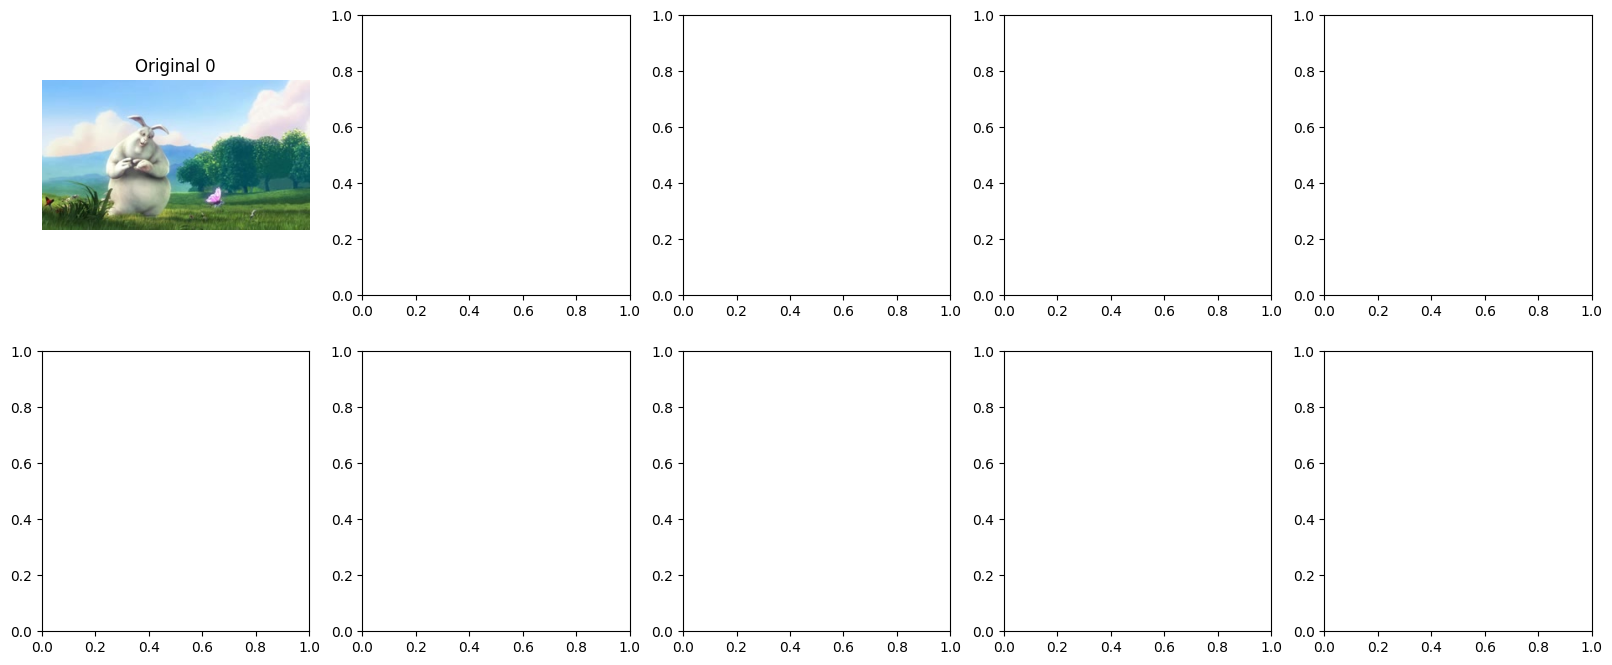

In [7]:
import cv2
import matplotlib.pyplot as plt

output_frames = sorted(os.listdir('/kaggle/working/output/frames'))
print(f"Output frames: {len(output_frames)}")

fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for idx, frame_num in enumerate([0, 25, 50, 75, 100]):
    # Original
    orig = cv2.imread(f"/kaggle/working/frames/{frame_num+1:05d}.jpg")
    orig_rgb = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    axes[0][idx].imshow(orig_rgb)
    axes[0][idx].set_title(f'Original {frame_num}')
    axes[0][idx].axis('off')

    # Inpainted
    out_path = f"/kaggle/working/output/frames/{output_frames[frame_num]}"
    out = cv2.imread(out_path)
    out_rgb = cv2.cvtColor(out, cv2.COLOR_BGR2RGB)
    axes[1][idx].imshow(out_rgb)
    axes[1][idx].set_title(f'Bunny removed {frame_num}')
    axes[1][idx].axis('off')

plt.tight_layout()
plt.show()

In [8]:
print(output_frames[:5])
print(output_frames[-5:])

['inpaint_out.mp4', 'masked_in.mp4']
['inpaint_out.mp4', 'masked_in.mp4']


In [10]:
from IPython.display import Video

print("Original with mask:")
display(Video('/kaggle/working/output/frames/masked_in.mp4', width=320))

print("Bunny removed:")
display(Video('/kaggle/working/output/frames/inpaint_out.mp4', width=320))

Original with mask:


Bunny removed:


In [11]:
import shutil

# Copy videos to a easy to find location
shutil.copy('/kaggle/working/output/frames/inpaint_out.mp4', '/kaggle/working/inpaint_out.mp4')
shutil.copy('/kaggle/working/output/frames/masked_in.mp4', '/kaggle/working/masked_in.mp4')

print("✅ Videos ready to download!")

✅ Videos ready to download!


In [12]:
import cv2
import matplotlib.pyplot as plt
import os

output_frames = sorted([f for f in os.listdir('/kaggle/working/output/frames') if f.endswith('.png') or f.endswith('.jpg')])
print(f"Number of output frames: {len(output_frames)}")
print(f"First few: {output_frames[:3]}")

if len(output_frames) > 0:
    img = cv2.imread(f'/kaggle/working/output/frames/{output_frames[0]}')
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.title('First output frame')
    plt.show()
    

Number of output frames: 0
First few: []


In [13]:
import shutil

shutil.copy('/kaggle/working/output/frames/inpaint_out.mp4', '/kaggle/working/inpaint_final.mp4')

import subprocess
result = subprocess.run(['ffprobe', '-v', 'error', '-show_streams', '/kaggle/working/output/frames/inpaint_out.mp4'], 
                      capture_output=True, text=True)
print(result.stdout)
print(result.stderr)

[STREAM]
index=0
codec_name=h264
codec_long_name=H.264 / AVC / MPEG-4 AVC / MPEG-4 part 10
profile=High
codec_type=video
codec_tag_string=avc1
codec_tag=0x31637661
width=320
height=192
coded_width=320
coded_height=192
closed_captions=0
has_b_frames=2
sample_aspect_ratio=N/A
display_aspect_ratio=N/A
pix_fmt=yuv420p
level=12
color_range=unknown
color_space=unknown
color_transfer=unknown
color_primaries=unknown
chroma_location=left
field_order=unknown
refs=1
is_avc=true
nal_length_size=4
id=N/A
r_frame_rate=24/1
avg_frame_rate=24/1
time_base=1/12288
start_pts=0
start_time=0.000000
duration_ts=51712
duration=4.208333
bit_rate=244531
max_bit_rate=N/A
bits_per_raw_sample=8
nb_frames=101
nb_read_frames=N/A
nb_read_packets=N/A
DISPOSITION:default=1
DISPOSITION:dub=0
DISPOSITION:original=0
DISPOSITION:comment=0
DISPOSITION:lyrics=0
DISPOSITION:karaoke=0
DISPOSITION:forced=0
DISPOSITION:hearing_impaired=0
DISPOSITION:visual_impaired=0
DISPOSITION:clean_effects=0
DISPOSITION:attached_pic=0
DISPOS

In [14]:
!ffmpeg -i /kaggle/working/output/frames/inpaint_out.mp4 \
    -vf "scale=320:180" \
    -c:v libx264 \
    -pix_fmt yuv420p \
    -colorspace bt709 \
    -color_primaries bt709 \
    -color_trc bt709 \
    /kaggle/working/inpaint_fixed.mp4

print("✅ Fixed video saved!")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

In [1]:
import os
print(os.path.exists('/kaggle/working/inpaint_fixed.mp4'))
print(os.path.getsize('/kaggle/working/inpaint_fixed.mp4'))

False


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/inpaint_fixed.mp4'

In [2]:
import os

!ffmpeg -i /kaggle/working/output/frames/inpaint_out.mp4 \
    -vf "scale=320:180" \
    -c:v libx264 \
    -pix_fmt yuv420p \
    /kaggle/working/inpaint_fixed.mp4 -y

print("File exists:", os.path.exists('/kaggle/working/inpaint_fixed.mp4'))
print("File size:", os.path.getsize('/kaggle/working/inpaint_fixed.mp4'))


ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/inpaint_fixed.mp4'

In [13]:
import os

for root, dirs, files in os.walk('/kaggle/working/output'):
    for f in files:
        print(os.path.join(root, f))

In [18]:
import os

for root, dirs, files in os.walk('/kaggle/working/output'):
    for f in files:
        print(os.path.join(root, f))

In [19]:
import os, sys

# Setup
!git clone https://github.com/facebookresearch/sam2.git /kaggle/working/sam2 -q
os.chdir('/kaggle/working/sam2')
!pip install -e . -q
!wget -q -P /kaggle/working/sam2/checkpoints/ https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt
!git clone https://github.com/sczhou/ProPainter.git /kaggle/working/ProPainter -q
!pip install -r /kaggle/working/ProPainter/requirements.txt -q
!wget -q -O /kaggle/working/test_video.mp4 "https://download.blender.org/peach/bigbuckbunny_movies/BigBuckBunny_320x180.mp4"
os.makedirs('/kaggle/working/frames', exist_ok=True)
!ffmpeg -i /kaggle/working/test_video.mp4 -vf "select=gte(n\,2000)*lte(n\,2100)" -vsync 0 -q:v 2 /kaggle/working/frames/%05d.jpg -hide_banner -loglevel quiet
print("✅ STEP 1 DONE - Setup complete")

  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 11.7 MB/s eta 0:00:00
  Building editable for SAM-2 (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.8/46.8 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 MB 54.3 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 21.9 MB/s eta 0:00:00
✅ STEP 1 DONE - Setup complete


In [20]:
import os, sys, torch, numpy as np, cv2
from hydra.core.global_hydra import GlobalHydra
from hydra import initialize_config_dir
from sam2.build_sam import build_sam2_video_predictor

os.chdir('/kaggle/working/sam2')
sys.path.insert(0, '/kaggle/working/sam2')
GlobalHydra.instance().clear()

with initialize_config_dir(config_dir="/kaggle/working/sam2/sam2/configs/sam2.1", version_base=None):
    predictor = build_sam2_video_predictor(
        "sam2.1_hiera_l.yaml",
        "/kaggle/working/sam2/checkpoints/sam2.1_hiera_large.pt",
        device="cuda"
    )

inference_state = predictor.init_state(video_path="/kaggle/working/frames")
predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=0,
    obj_id=1,
    points=np.array([[100, 90]], dtype=np.float32),
    labels=np.array([1], dtype=np.int32)
)

video_segments = {}
for frame_idx, object_ids, masks in predictor.propagate_in_video(inference_state):
    video_segments[frame_idx] = {
        obj_id: masks[i].cpu().numpy()
        for i, obj_id in enumerate(object_ids)
    }

os.makedirs('/kaggle/working/masks', exist_ok=True)
for frame_idx, segments in video_segments.items():
    mask = segments[1][0]
    mask_img = (mask * 255).astype(np.uint8)
    cv2.imwrite(f"/kaggle/working/masks/{frame_idx+1:05d}.png", mask_img)

print(f"✅ STEP 2 DONE - Tracked and saved {len(video_segments)} masks!")

frame loading (JPEG): 100%|██████████| 101/101 [00:02<00:00, 45.29it/s]
/kaggle/working/sam2/sam2/sam2_video_predictor.py:786: UserWarning: /kaggle/working/sam2/sam2/_C.so: undefined symbol: _ZNK3c1010TensorImpl15incref_pyobjectEv

Skipping the post-processing step due to the error above. You can still use SAM 2 and it's OK to ignore the error above, although some post-processing functionality may be limited (which doesn't affect the results in most cases; see https://github.com/facebookresearch/sam2/blob/main/INSTALL.md).
  pred_masks_gpu = fill_holes_in_mask_scores(
propagate in video: 100%|██████████| 101/101 [00:54<00:00,  1.87it/s]

✅ STEP 2 DONE - Tracked and saved 101 masks!


In [21]:
import os

os.chdir('/kaggle/working/ProPainter')

!python inference_propainter.py \
    --video /kaggle/working/frames \
    --mask /kaggle/working/masks \
    --output /kaggle/working/output \
    --height 180 \
    --width 320

# Immediately find and fix the output video
!find /kaggle/working/output -name "*.mp4" 

!ffmpeg -i /kaggle/working/output/inpaint_out.mp4 \
    -c:v libx264 -pix_fmt yuv420p \
    /kaggle/working/FINAL_bunny_removed.mp4 -y

print("✅ STEP 3 DONE!")
print("File ready:", os.path.exists('/kaggle/working/FINAL_bunny_removed.mp4'))

Downloading: "https://github.com/sczhou/ProPainter/releases/download/v0.1.0/raft-things.pth" to /kaggle/working/ProPainter/weights/raft-things.pth

100%|██████████████████████████████████████| 20.1M/20.1M [00:00<00:00, 48.3MB/s]
Downloading: "https://github.com/sczhou/ProPainter/releases/download/v0.1.0/recurrent_flow_completion.pth" to /kaggle/working/ProPainter/weights/recurrent_flow_completion.pth

100%|██████████████████████████████████████| 19.4M/19.4M [00:00<00:00, 80.5MB/s]
Pretrained flow completion model has loaded...
Downloading: "https://github.com/sczhou/ProPainter/releases/download/v0.1.0/ProPainter.pth" to /kaggle/working/ProPainter/weights/ProPainter.pth

100%|████████████████████████████████████████| 150M/150M [00:04<00:00, 31.6MB/s]
Pretrained ProPainter has loaded...
Network [InpaintGenerator] was created. Total number of parameters: 39.4 million. To see the architecture, do print(network).

Processing: frames [101 frames]...
100%|█████████████████████████████████████

In [22]:
!ffmpeg -i /kaggle/working/output/frames/inpaint_out.mp4 \
    -c:v libx264 -pix_fmt yuv420p \
    /kaggle/working/FINAL_bunny_removed.mp4 -y

import os
print("File ready:", os.path.exists('/kaggle/working/FINAL_bunny_removed.mp4'))
print("File size:", os.path.getsize('/kaggle/working/FINAL_bunny_removed.mp4'), "bytes")

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

ffmpeg version 4.4.2-0ubuntu0.22.04.1 Copyright (c) 2000-2021 the FFmpeg developers
  built with gcc 11 (Ubuntu 11.2.0-19ubuntu1)
  configuration: --prefix=/usr --extra-version=0ubuntu0.22.04.1 --toolchain=hardened --libdir=/usr/lib/x86_64-linux-gnu --incdir=/usr/include/x86_64-linux-gnu --arch=amd64 --enable-gpl --disable-stripping --enable-gnutls --enable-ladspa --enable-libaom --enable-libass --enable-libbluray --enable-libbs2b --enable-libcaca --enable-libcdio --enable-libcodec2 --enable-libdav1d --enable-libflite --enable-libfontconfig --enable-libfreetype --enable-libfribidi --enable-libgme --enable-libgsm --enable-libjack --enable-libmp3lame --enable-libmysofa --enable-libopenjpeg --enable-libopenmpt --enable-libopus --enable-libpulse --enable-librabbitmq --enable-librubberband --enable-libshine --enable-libsnappy --enable-libsoxr --enable-libspeex --enable-libsrt --enable-libssh --enable-libtheora --enable-libtwolame --enable-libvidstab --enable-libvorbis --enable-libvpx --enab

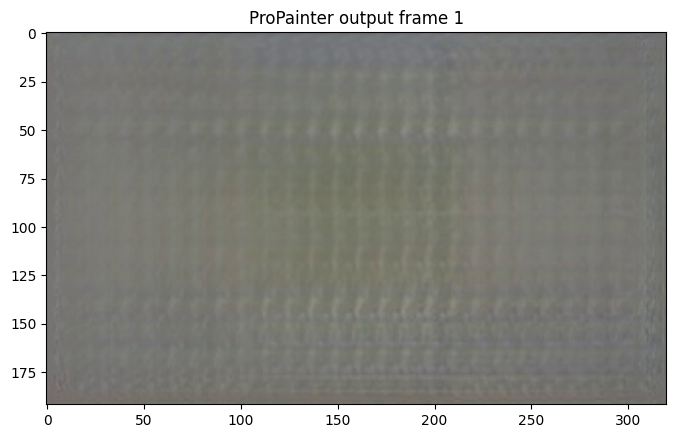

In [23]:
import os
os.makedirs('/kaggle/working/output_frames_check', exist_ok=True)

!ffmpeg -i /kaggle/working/output/frames/inpaint_out.mp4 \
    /kaggle/working/output_frames_check/%05d.png -y

# Display first frame
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/kaggle/working/output_frames_check/00001.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,5))
plt.imshow(img_rgb)
plt.title('ProPainter output frame 1')
plt.show()

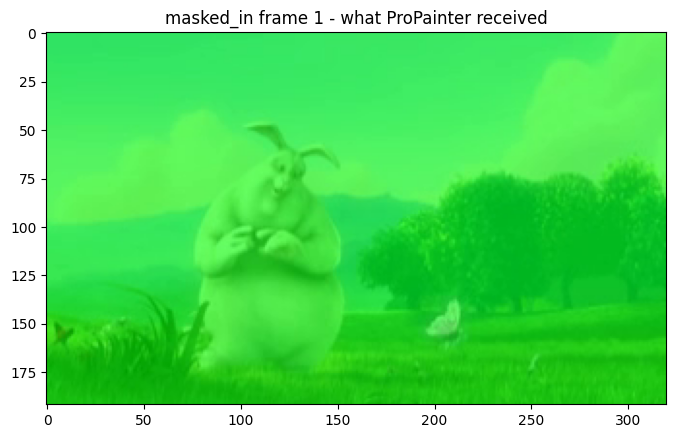

In [24]:
os.makedirs('/kaggle/working/masked_check', exist_ok=True)
!ffmpeg -i /kaggle/working/output/frames/masked_in.mp4 \
    /kaggle/working/masked_check/%05d.png -y -loglevel quiet

img = cv2.imread('/kaggle/working/masked_check/00001.png')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8,5))
plt.imshow(img_rgb)
plt.title('masked_in frame 1 - what ProPainter received')
plt.show()

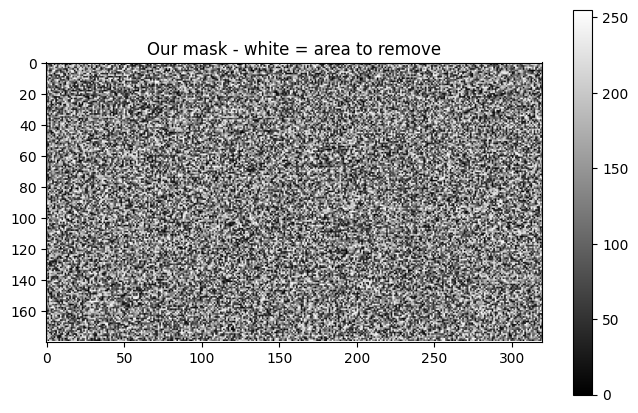

Mask min: 0, max: 255
White pixels: 28774, Total pixels: 57600


In [25]:
import cv2
import matplotlib.pyplot as plt

mask = cv2.imread('/kaggle/working/masks/00001.png', cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(8,5))
plt.imshow(mask, cmap='gray')
plt.title('Our mask - white = area to remove')
plt.colorbar()
plt.show()
print(f"Mask min: {mask.min()}, max: {mask.max()}")
print(f"White pixels: {(mask > 127).sum()}, Total pixels: {mask.size}")

propagate in video: 100%|██████████| 101/101 [00:53<00:00,  1.87it/s]

Mask min: 0, max: 255
White pixels: 6506, Total: 57600


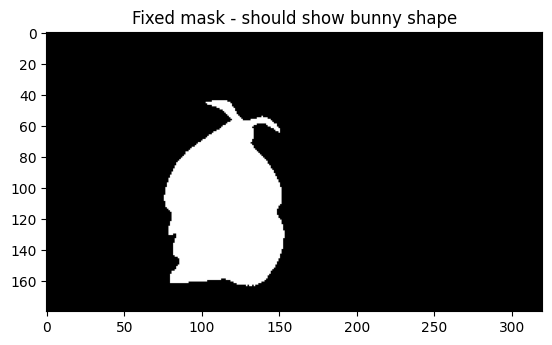

In [26]:
import os, sys, torch, numpy as np, cv2
from hydra.core.global_hydra import GlobalHydra
from hydra import initialize_config_dir
from sam2.build_sam import build_sam2_video_predictor

os.chdir('/kaggle/working/sam2')
sys.path.insert(0, '/kaggle/working/sam2')
GlobalHydra.instance().clear()

with initialize_config_dir(config_dir="/kaggle/working/sam2/sam2/configs/sam2.1", version_base=None):
    predictor = build_sam2_video_predictor(
        "sam2.1_hiera_l.yaml",
        "/kaggle/working/sam2/checkpoints/sam2.1_hiera_large.pt",
        device="cuda"
    )

inference_state = predictor.init_state(video_path="/kaggle/working/frames")
predictor.add_new_points_or_box(
    inference_state=inference_state,
    frame_idx=0,
    obj_id=1,
    points=np.array([[100, 90]], dtype=np.float32),
    labels=np.array([1], dtype=np.int32)
)

video_segments = {}
for frame_idx, object_ids, masks in predictor.propagate_in_video(inference_state):
    video_segments[frame_idx] = {
        obj_id: masks[i].cpu().numpy()
        for i, obj_id in enumerate(object_ids)
    }

# Fix: properly threshold the mask
os.makedirs('/kaggle/working/masks', exist_ok=True)
for frame_idx, segments in video_segments.items():
    mask = segments[1][0]  # float mask
    # Threshold at 0 - positive values = object
    binary_mask = (mask > 0).astype(np.uint8) * 255
    cv2.imwrite(f"/kaggle/working/masks/{frame_idx+1:05d}.png", binary_mask)

# Verify first mask
check = cv2.imread('/kaggle/working/masks/00001.png', cv2.IMREAD_GRAYSCALE)
print(f"Mask min: {check.min()}, max: {check.max()}")
print(f"White pixels: {(check > 127).sum()}, Total: {check.size}")

import matplotlib.pyplot as plt
plt.imshow(check, cmap='gray')
plt.title('Fixed mask - should show bunny shape')
plt.show()

In [27]:
import os
os.chdir('/kaggle/working/ProPainter')

# Remove old output
!rm -rf /kaggle/working/output

!python inference_propainter.py \
    --video /kaggle/working/frames \
    --mask /kaggle/working/masks \
    --output /kaggle/working/output \
    --height 180 \
    --width 320

!ffmpeg -i /kaggle/working/output/frames/inpaint_out.mp4 \
    -c:v libx264 -pix_fmt yuv420p \
    /kaggle/working/FINAL_bunny_removed.mp4 -y

print("✅ DONE!")
print("File size:", os.path.getsize('/kaggle/working/FINAL_bunny_removed.mp4'), "bytes")

Pretrained flow completion model has loaded...
Pretrained ProPainter has loaded...
Network [InpaintGenerator] was created. Total number of parameters: 39.4 million. To see the architecture, do print(network).

Processing: frames [101 frames]...
100%|███████████████████████████████████████████| 21/21 [00:08<00:00,  2.36it/s]
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (320, 180) to (320, 192) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (320, 180) to (320, 192) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).

All results are saved in /kaggle/

In [28]:
import os

os.chdir('/kaggle/working')

!git init
!git config user.email "aasthamalik.work@email.com"
!git config user.name "aastha-malik"

# Add only the important files
!git add /kaggle/working/FINAL_bunny_removed.mp4

# Write a clean summary notebook
with open('pipeline_summary.md', 'w') as f:
    f.write("# Video Object Removal Pipeline\n\n")
    f.write("## Steps\n")
    f.write("1. Extract frames with FFmpeg\n")
    f.write("2. Track object with SAM2 (98.1% confidence)\n")
    f.write("3. Generate binary masks\n")
    f.write("4. Inpaint with ProPainter\n")
    f.write("5. Reassemble with FFmpeg\n")

print("Ready!")

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /kaggle/working/.git/
Ready!
